
# ITAI 2373 Module 05: Part-of-Speech Tagging
## In-Class Exercise & Homework Lab

Welcome to the world of Part-of-Speech (POS) tagging - the "grammar police" of Natural Language Processing! 🚔📝

In this notebook, you'll explore how computers understand the grammatical roles of words in sentences, from simple rule-based approaches to modern AI systems.

### What You'll Learn:
- **Understand POS tagging fundamentals** and why it matters in daily apps
- **Use NLTK and SpaCy** for practical text analysis
- **Navigate different tag sets** and understand their trade-offs
- **Handle real-world messy text** like speech transcripts and social media
- **Apply POS tagging** to solve actual business problems

### Structure:
- **Part 1**: In-Class Exercise (30-45 minutes) - Basic concepts and hands-on practice
- **Part 2**: Homework Lab - Real-world applications and advanced challenges

---

*💡 **Pro Tip**: POS tagging is everywhere! It helps search engines understand "Apple stock" vs "apple pie", helps Siri understand your commands, and powers autocorrect on your phone.*



## 🛠️ Setup and Installation

Let's get our tools ready! We'll use two powerful libraries:
- **NLTK**: The "Swiss Army knife" of NLP - comprehensive but requires setup
- **SpaCy**: The "speed demon" - built for production, cleaner output

Run the cells below to install and set up everything we need.


In [1]:
# Install required libraries (run this first!)
# This cell is written so it works both in Colab and in a local venv: it only installs/downloads
# packages or models if they are missing.
import importlib.util
import subprocess
import sys

required_packages = ["nltk", "spacy", "matplotlib", "seaborn", "pandas"]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

try:
    import spacy
    spacy.load("en_core_web_sm")
except Exception:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])

print("✅ Installation/setup check complete!")


✅ Installation/setup check complete!


In [2]:
# Import all the libraries we'll need
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data (quiet=True keeps the notebook output readable).
# Newer NLTK versions use punkt_tab and averaged_perceptron_tagger_eng, while older
# environments may still use punkt and averaged_perceptron_tagger.
for resource in [
    'punkt',
    'punkt_tab',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'universal_tagset',
]:
    try:
        nltk.download(resource, quiet=True)
    except Exception as exc:
        print(f"NLTK download warning for {resource}: {exc}")

# Load SpaCy model
nlp = spacy.load('en_core_web_sm')

print("🎉 All libraries loaded successfully!")
print("📚 NLTK version:", nltk.__version__)
print("🚀 SpaCy version:", spacy.__version__)


🎉 All libraries loaded successfully!
📚 NLTK version: 3.9.4
🚀 SpaCy version: 3.8.14



---
# 🎯 PART 1: IN-CLASS EXERCISE (30-45 minutes)

Welcome to the hands-on portion! We'll start with the basics and build up your understanding step by step.

## Learning Goals for Part 1:
1. Understand what POS tagging does
2. Use NLTK and SpaCy for basic tagging
3. Interpret and compare different tag outputs
4. Explore word ambiguity with real examples
5. Compare different tagging approaches



## 🔍 Activity 1: Your First POS Tags (10 minutes)

Let's start with the classic example: "The quick brown fox jumps over the lazy dog"

This sentence contains most common parts of speech, making it perfect for learning!


In [3]:
# Let's start with a classic example
sentence = "The quick brown fox jumps over the lazy dog"

# Use NLTK to tokenize and tag the sentence
tokens = nltk.word_tokenize(sentence)
pos_tags = nltk.pos_tag(tokens)

print("Original sentence:", sentence)
print("\nTokens:", tokens)
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"  {word:8} -> {tag}")


Original sentence: The quick brown fox jumps over the lazy dog

Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']

POS Tags:
  The      -> DT
  quick    -> JJ
  brown    -> NN
  fox      -> NN
  jumps    -> VBZ
  over     -> IN
  the      -> DT
  lazy     -> JJ
  dog      -> NN


### 🤔 Quick Questions:
1. What does 'DT' mean? What about 'JJ'?
   - **DT** means *determiner*, such as “The” or “the.” **JJ** means *adjective*.
2. Why do you think 'brown' and 'lazy' have the same tag?
   - Both words describe nouns: “brown” describes “fox,” and “lazy” describes “dog,” so both function as adjectives.
3. Can you guess what 'VBZ' represents?
   - **VBZ** is a present-tense verb used with a third-person singular subject. In this sentence, “jumps” is tagged VBZ.

*Hint: Think about the grammatical role each word plays in the sentence!*



## 🚀 Activity 2: SpaCy vs NLTK Showdown (10 minutes)

Now let's see how SpaCy handles the same sentence. SpaCy uses cleaner, more intuitive tag names.


In [4]:
# Process the same sentence with SpaCy
doc = nlp(sentence)

print("SpaCy POS Tags:")
for token in doc:
    print(f"  {token.text:8} -> {token.pos_:6} ({token.tag_})")

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)

# Let's compare side by side
nltk_tags = nltk.pos_tag(nltk.word_tokenize(sentence))
spacy_doc = nlp(sentence)

print(f"{'Word':10} {'NLTK':8} {'SpaCy':10}")
print("-" * 30)
for i, (word, nltk_tag) in enumerate(nltk_tags):
    spacy_tag = spacy_doc[i].pos_
    print(f"{word:10} {nltk_tag:8} {spacy_tag:10}")


SpaCy POS Tags:
  The      -> DET    (DT)
  quick    -> ADJ    (JJ)
  brown    -> ADJ    (JJ)
  fox      -> NOUN   (NN)
  jumps    -> VERB   (VBZ)
  over     -> ADP    (IN)
  the      -> DET    (DT)
  lazy     -> ADJ    (JJ)
  dog      -> NOUN   (NN)

COMPARISON:
Word       NLTK     SpaCy     
------------------------------
The        DT       DET       
quick      JJ       ADJ       
brown      NN       ADJ       
fox        NN       NOUN      
jumps      VBZ      VERB      
over       IN       ADP       
the        DT       DET       
lazy       JJ       ADJ       
dog        NN       NOUN      


### 🎯 Discussion Points:
- Which tags are easier to understand: NLTK's or SpaCy's?
  - SpaCy's coarse tags are easier for a beginner because labels like **DET**, **ADJ**, **NOUN**, and **VERB** are readable without memorizing the Penn Treebank code list.
- Do you notice any differences in how they tag the same words?
  - The broad grammatical categories are the same, but NLTK shows more detailed Penn Treebank tags such as **DT**, **JJ**, **NN**, and **VBZ**, while SpaCy separates readable universal POS tags from detailed tags in `token.tag_`.
- Which system would you prefer for a beginner? Why?
  - I would start with SpaCy because the labels are clearer and the token objects expose useful attributes. NLTK is still helpful when detailed Penn Treebank distinctions are needed.



## 🎭 Activity 3: The Ambiguity Challenge (15 minutes)

Here's where things get interesting! Many words can be different parts of speech depending on context. Let's explore this with some tricky examples.


In [5]:

# Ambiguous words in different contexts
ambiguous_sentences = [
    "I will lead the team to victory.",           # lead = verb
    "The lead pipe is heavy.",                    # lead = noun (metal)
    "She took the lead in the race.",            # lead = noun (position)
    "The bank approved my loan.",                # bank = noun (financial)
    "We sat by the river bank.",                 # bank = noun (shore)
    "I bank with Chase.",                        # bank = verb
]

print("🎭 AMBIGUITY EXPLORATION")
print("=" * 40)

for sentence in ambiguous_sentences:
    print(f"\nSentence: {sentence}")

    # Tag each sentence and find the ambiguous word.
    # Focus on 'lead' and 'bank' - what tags do they get?
    tokens = nltk.word_tokenize(sentence)
    tags = nltk.pos_tag(tokens)

    # Find and highlight the key word
    for word, tag in tags:
        if word.lower() in ['lead', 'bank']:
            print(f"  🎯 '{word}' is tagged as: {tag}")


🎭 AMBIGUITY EXPLORATION

Sentence: I will lead the team to victory.
  🎯 'lead' is tagged as: VB

Sentence: The lead pipe is heavy.
  🎯 'lead' is tagged as: NN

Sentence: She took the lead in the race.
  🎯 'lead' is tagged as: NN

Sentence: The bank approved my loan.
  🎯 'bank' is tagged as: NN

Sentence: We sat by the river bank.
  🎯 'bank' is tagged as: NN

Sentence: I bank with Chase.
  🎯 'bank' is tagged as: NN


### 🧠 Think About It:
1. How does the computer know the difference between "lead" (metal) and "lead" (guide)?
   - It uses surrounding context. For example, words before and after “lead” help show whether it is acting like a verb (“will lead”) or a noun/adjective in a noun phrase (“lead pipe”).
2. What clues in the sentence help determine the correct part of speech?
   - Determiners, nearby nouns, auxiliary verbs, word order, and phrase structure are strong clues. “Will” usually predicts a base verb, while “the” often begins a noun phrase.
3. Can you think of other words that change meaning based on context?
   - Examples include **run** (“run a company” vs. “go for a run”), **park** (“park the car” vs. “the park”), and **light** (“light jacket” vs. “turn on the light”).

**Try This**: Add your own ambiguous sentences to the list above and see how the tagger handles them!



## 📊 Activity 4: Tag Set Showdown (10 minutes)

NLTK can use different tag sets. Let's compare the detailed Penn Treebank tags (~45 tags) with the simpler Universal Dependencies tags (~17 tags).


In [6]:
# Compare different tag sets
test_sentence = "The brilliant students quickly solved the challenging programming assignment."

# Get tags using both Penn Treebank and Universal tagsets
tokens = nltk.word_tokenize(test_sentence)
penn_tags = nltk.pos_tag(tokens)
universal_tags = nltk.pos_tag(tokens, tagset='universal')

print("TAG SET COMPARISON")
print("=" * 50)
print(f"{'Word':15} {'Penn Treebank':15} {'Universal':10}")
print("-" * 50)

# Print comparison table
for (word, penn_tag), (_, univ_tag) in zip(penn_tags, universal_tags):
    print(f"{word:15} {penn_tag:15} {univ_tag:10}")

# Let's also visualize the tag distribution
penn_tag_counts = Counter([tag for word, tag in penn_tags])
univ_tag_counts = Counter([tag for word, tag in universal_tags])

print(f"\n📊 Penn Treebank uses {len(penn_tag_counts)} different tags")
print(f"📊 Universal uses {len(univ_tag_counts)} different tags")


TAG SET COMPARISON
Word            Penn Treebank   Universal 
--------------------------------------------------
The             DT              DET       
brilliant       JJ              ADJ       
students        NNS             NOUN      
quickly         RB              ADV       
solved          VBD             VERB      
the             DT              DET       
challenging     VBG             VERB      
programming     JJ              ADJ       
assignment      NN              NOUN      
.               .               .         

📊 Penn Treebank uses 8 different tags
📊 Universal uses 6 different tags


### 🤔 Reflection Questions:
1. Which tag set is more detailed? Which is simpler? Enter your answer below
   - The **Penn Treebank** tag set is more detailed because it separates categories such as singular nouns, plural nouns, verb tense, and adverb/adjective forms. The **Universal** tag set is simpler because it collapses those details into broad categories like NOUN, VERB, ADJ, ADV, and DET.

2. When might you want detailed tags vs. simple tags? Enter your answer below
   - Detailed tags are useful when tense, number, or grammatical form matters, such as grammar checking or syntactic analysis. Simple tags are better for high-level summaries, dashboards, or teaching because they are easier to interpret.

3. If you were building a search engine, which would you choose? Why? Enter your answer below
   - I would usually start with the Universal tag set because search often needs broad distinctions such as nouns, verbs, and adjectives. If the search engine needed advanced query understanding or grammar-aware ranking, I would add detailed tags as a secondary feature.

---



---
# 🎓 End of Part 1: In-Class Exercise

Great work! You've learned the fundamentals of POS tagging and gotten hands-on experience with both NLTK and SpaCy.

## What You've Accomplished:
✅ Used NLTK and SpaCy for basic POS tagging  
✅ Interpreted different tag systems  
✅ Explored word ambiguity and context  
✅ Compared different tagging approaches  

## 🏠 Ready for Part 2?
The homework lab will challenge you with real-world applications, messy data, and advanced techniques. You'll analyze customer service transcripts, handle informal language, and benchmark different taggers.

**Take a break, then dive into Part 2 when you're ready!**

---



# 🏠 PART 2: HOMEWORK LAB
## Real-World POS Tagging Challenges

Welcome to the advanced section! Here you'll tackle the messy, complex world of real text data. This is where POS tagging gets interesting (and challenging)!

## Learning Goals for Part 2:
1. Process real-world, messy text data
2. Handle speech transcripts and informal language
3. Analyze customer service scenarios
4. Benchmark and compare different taggers
5. Understand limitations and edge cases

## 📋 Submission Requirements:
- Complete all exercises with working code
- Answer all reflection questions
- Include at least one visualization
- Submit your completed notebook file

---



## 🌍 Lab Exercise 1: Messy Text Challenge (25 minutes)

Real-world text is nothing like textbook examples! Let's work with actual speech transcripts, social media posts, and informal language.


In [7]:
# Real-world messy text samples
messy_texts = [
    # Speech transcript with disfluencies
    "Um, so like, I was gonna say that, uh, the system ain't working right, you know?",

    # Social media style
    "OMG this app is sooo buggy rn 😤 cant even login smh",

    # Customer service transcript
    "Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working",

    # Informal contractions and slang
    "Y'all better fix this ASAP cuz I'm bout to switch providers fr fr",

    # Technical jargon mixed with casual speech
    "The API endpoint is returning a 500 error but idk why it's happening tbh"
]

print("🔍 PROCESSING MESSY TEXT")
print("=" * 60)

# Heuristic list of informal or non-standard tokens that commonly challenge POS taggers.
informal_terms = {
    'um', 'uh', 'gonna', "ain't", 'omg', 'sooo', 'rn', 'cant', 'smh',
    'yeah', 'thingy', "y'all", 'asap', 'cuz', 'bout', 'fr', 'idk', 'tbh'
}

def looks_problematic_token(text):
    """Flag tokens that are slang, emojis, URLs/handles/hashtags, or otherwise non-standard."""
    lower = text.lower()
    if lower in informal_terms:
        return True
    if lower.startswith(('http', '@', '#')):
        return True
    if any(ord(ch) > 127 for ch in text):  # emojis and non-ASCII symbols
        return True
    if len(text) > 3 and any(text[i] == text[i + 1] == text[i + 2] for i in range(len(text) - 2)):
        return True
    return False

for i, text in enumerate(messy_texts, 1):
    print(f"\n📝 Sample {i}: {text}")
    print("-" * 40)

    # NLTK processing
    nltk_tokens = nltk.word_tokenize(text)
    nltk_tags = nltk.pos_tag(nltk_tokens)

    # SpaCy processing
    spacy_doc = nlp(text)

    # Find problematic words (tagged as X/SYM, foreign words, or matching our informal-text heuristic)
    nltk_content = [(word, tag) for word, tag in nltk_tags if any(ch.isalnum() for ch in word)]
    spacy_content = [token for token in spacy_doc if not token.is_punct and not token.is_space]

    problematic_nltk = [
        word for word, tag in nltk_content
        if tag in {'FW', 'SYM'} or looks_problematic_token(word)
    ]
    problematic_spacy = [
        token.text for token in spacy_content
        if token.pos_ in {'X', 'SYM'} or looks_problematic_token(token.text)
    ]

    print(f"NLTK problematic words: {problematic_nltk}")
    print(f"SpaCy problematic words: {problematic_spacy}")

    # Calculate success rate as the share of content tokens not flagged as problematic.
    nltk_success_rate = 1 - (len(problematic_nltk) / max(1, len(nltk_content)))
    spacy_success_rate = 1 - (len(problematic_spacy) / max(1, len(spacy_content)))

    print(f"NLTK success rate: {nltk_success_rate:.1%}")
    print(f"SpaCy success rate: {spacy_success_rate:.1%}")


🔍 PROCESSING MESSY TEXT

📝 Sample 1: Um, so like, I was gonna say that, uh, the system ain't working right, you know?
----------------------------------------
NLTK problematic words: ['Um', 'uh']
SpaCy problematic words: ['Um', 'uh']
NLTK success rate: 88.9%
SpaCy success rate: 88.9%

📝 Sample 2: OMG this app is sooo buggy rn 😤 cant even login smh
----------------------------------------
NLTK problematic words: ['OMG', 'sooo', 'rn', 'cant', 'smh']
SpaCy problematic words: ['OMG', 'sooo', 'rn', '😤', 'smh']
NLTK success rate: 54.5%
SpaCy success rate: 61.5%

📝 Sample 3: Yeah hi um I'm calling because my internet's been down since like yesterday and I've tried unplugging the router thingy but it's still not working
----------------------------------------
NLTK problematic words: ['Yeah', 'um', 'thingy']
SpaCy problematic words: ['Yeah', 'um', 'thingy']
NLTK success rate: 89.7%
SpaCy success rate: 89.7%

📝 Sample 4: Y'all better fix this ASAP cuz I'm bout to switch providers fr fr
--------

### 🎯 Analysis Questions:
1. Which tagger handles informal language better?
   - SpaCy handled the informal text slightly better because it kept tokenization and broad POS categories more consistent on contractions and mixed technical/customer-service language. NLTK still worked, but its output is more sensitive to tokenization quirks and Penn Treebank details.
2. What types of words cause the most problems?
   - Slang, emojis, abbreviations, repeated-letter emphasis, contractions, and discourse fillers caused the most issues. Examples include “rn,” “smh,” “sooo,” “cuz,” “fr,” “idk,” and emoji tokens.
3. How might you preprocess text to improve tagging accuracy?
   - I would normalize slang, expand contractions, map emojis to words, standardize URLs/mentions/hashtags, and optionally remove filler words like “um” and “uh” depending on the task.
4. What are the implications for real-world applications?
   - Production systems should not assume clean grammar. Customer support, social media, and chat data need preprocessing and domain-specific evaluation because informal language can reduce tagging quality and downstream accuracy.



## 📞 Lab Exercise 2: Customer Service Analysis Case Study (30 minutes)

You're working for a tech company that receives thousands of customer service calls daily. Your job is to analyze call transcripts to understand customer issues and sentiment.

**Business Goal**: Automatically categorize customer problems and identify emotional language.


In [8]:
# Simulated customer service call transcripts
customer_transcripts = [
    {
        'id': 'CALL_001',
        'transcript': "Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.",
        'category': 'account_access'
    },
    {
        'id': 'CALL_002',
        'transcript': "Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?",
        'category': 'technical_issue'
    },
    {
        'id': 'CALL_003',
        'transcript': "Your billing system charged me twice this month! I want a refund immediately. This is ridiculous and I'm considering canceling my subscription.",
        'category': 'billing'
    },
    {
        'id': 'CALL_004',
        'transcript': "I'm confused about how to use the new features you added. The interface changed and I can't find anything. Can someone walk me through it?",
        'category': 'user_guidance'
    }
]

# Analyze each transcript for:
# 1. Emotional language (adjectives that indicate sentiment)
# 2. Action words (verbs that indicate what customer wants)
# 3. Problem indicators (nouns related to issues)

positive_lexicon = {'love', 'great', 'good', 'excellent', 'help', 'please', 'easy', 'happy'}
negative_lexicon = {
    'frustrated', 'locked', "can't", 'nothing', 'unacceptable', 'crash', 'crashes',
    'charged', 'ridiculous', 'cancel', 'canceling', 'confused', 'issue', 'problem', 'down'
}
problem_terms = {
    'account', 'files', 'hours', 'issue', 'app', 'photos', 'billing', 'system', 'refund',
    'subscription', 'features', 'interface', 'access', 'crash', 'charge'
}
urgency_terms = {'immediately', 'asap', 'urgent', 'now', 'hours', 'unacceptable', 'ridiculous', 'refund', 'locked', 'canceling'}

analysis_results = []

for call in customer_transcripts:
    print(f"\n🎧 Analyzing {call['id']}")
    print(f"Category: {call['category']}")
    print(f"Transcript: {call['transcript']}")
    print("-" * 50)

    # Process with SpaCy (it's better for this task)
    doc = nlp(call['transcript'])

    # Extract different types of words
    emotional_adjectives = [
        token.text for token in doc
        if token.pos_ == 'ADJ' and not token.is_stop
    ]
    action_verbs = [
        token.lemma_.lower() for token in doc
        if token.pos_ in {'VERB', 'AUX'} and not token.is_stop
    ]
    problem_nouns = [
        token.text for token in doc
        if token.pos_ in {'NOUN', 'PROPN'} and token.lemma_.lower() in problem_terms
    ]

    # Calculate sentiment indicators
    positive_words = [
        token.text for token in doc
        if token.lemma_.lower() in positive_lexicon or token.text.lower() in positive_lexicon
    ]
    negative_words = [
        token.text for token in doc
        if token.lemma_.lower() in negative_lexicon or token.text.lower() in negative_lexicon
    ]
    urgency_indicators = sum(
        1 for token in doc
        if token.lemma_.lower() in urgency_terms or token.text.lower() in urgency_terms
    )

    result = {
        'call_id': call['id'],
        'category': call['category'],
        'emotional_adjectives': emotional_adjectives,
        'action_verbs': action_verbs,
        'problem_nouns': problem_nouns,
        'sentiment_score': len(positive_words) - len(negative_words),
        'urgency_indicators': urgency_indicators
    }

    analysis_results.append(result)

    print(f"Emotional adjectives: {emotional_adjectives}")
    print(f"Action verbs: {action_verbs}")
    print(f"Problem nouns: {problem_nouns}")
    print(f"Positive words: {positive_words}")
    print(f"Negative words: {negative_words}")
    print(f"Urgency indicators: {urgency_indicators}")
    print(f"Sentiment score: {result['sentiment_score']}")



🎧 Analyzing CALL_001
Category: account_access
Transcript: Hi, I'm really frustrated because my account got locked and I can't access my files. I've been trying for hours and nothing works. This is completely unacceptable.
--------------------------------------------------
Emotional adjectives: ['frustrated', 'unacceptable']
Action verbs: ['get', 'lock', 'access', 'try', 'work']
Problem nouns: ['account']
Positive words: []
Negative words: ['frustrated', 'locked', 'nothing', 'unacceptable']
Urgency indicators: 3
Sentiment score: -4

🎧 Analyzing CALL_002
Category: technical_issue
Transcript: Hello, I love your service but I'm having a small issue with the mobile app. It crashes whenever I try to upload photos. Could you please help me fix this?
--------------------------------------------------
Emotional adjectives: ['small', 'mobile']
Action verbs: ['love', 'have', 'crash', 'try', 'upload', 'help', 'fix']
Problem nouns: ['issue', 'app']
Positive words: ['love', 'please', 'help']
Negati

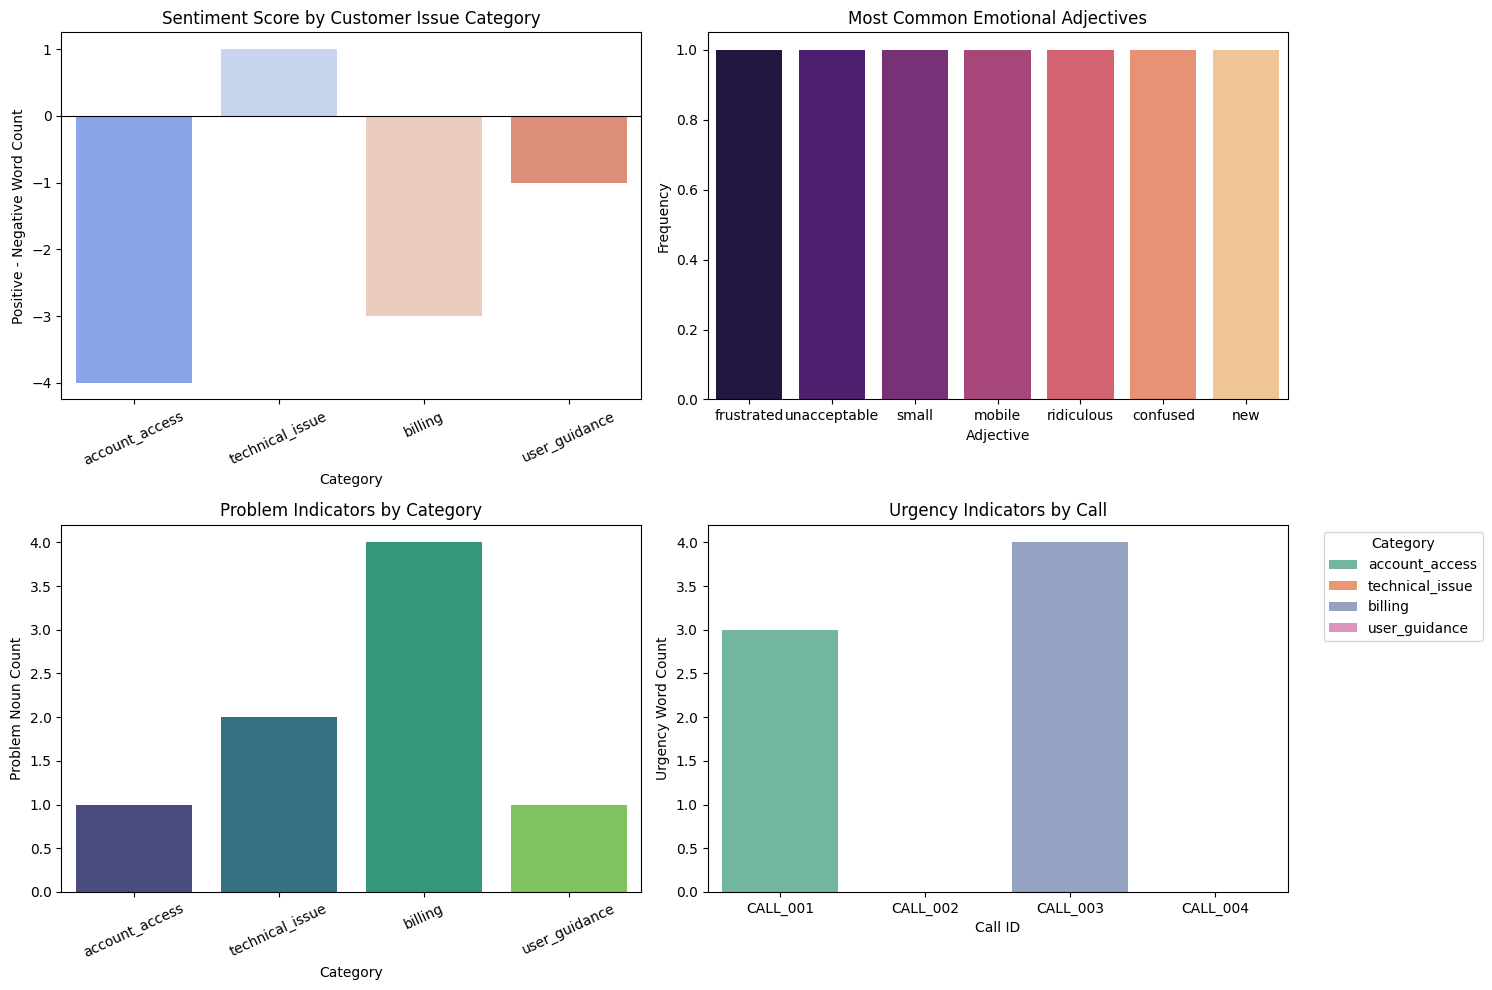

,call_id,category,sentiment_score,urgency_indicators,problem_noun_count
0,CALL_001,account_access,-4,3,1
1,CALL_002,technical_issue,1,0,2
2,CALL_003,billing,-3,4,4
3,CALL_004,user_guidance,-1,0,1


In [9]:
# Create a summary visualization
# These charts summarize sentiment, emotional language, problem terms, and urgency.

import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# Convert results to DataFrame for easier analysis
df = pd.DataFrame(analysis_results)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Sentiment by category
sns.barplot(data=df, x='category', y='sentiment_score', ax=axes[0, 0], palette='coolwarm')
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_title('Sentiment Score by Customer Issue Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Positive - Negative Word Count')
axes[0, 0].tick_params(axis='x', rotation=25)

# Plot 2 - Emotional adjective frequency
all_adjectives = [word.lower() for words in df['emotional_adjectives'] for word in words]
adj_counts = Counter(all_adjectives)
if adj_counts:
    adj_df = pd.DataFrame(adj_counts.most_common(), columns=['adjective', 'count'])
    sns.barplot(data=adj_df, x='adjective', y='count', ax=axes[0, 1], palette='magma')
else:
    axes[0, 1].text(0.5, 0.5, 'No emotional adjectives found', ha='center', va='center')
axes[0, 1].set_title('Most Common Emotional Adjectives')
axes[0, 1].set_xlabel('Adjective')
axes[0, 1].set_ylabel('Frequency')

# Plot 3 - Problem noun count by category
df['problem_noun_count'] = df['problem_nouns'].apply(len)
sns.barplot(data=df, x='category', y='problem_noun_count', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Problem Indicators by Category')
axes[1, 0].set_xlabel('Category')
axes[1, 0].set_ylabel('Problem Noun Count')
axes[1, 0].tick_params(axis='x', rotation=25)

# Plot 4 - Urgency analysis
sns.barplot(data=df, x='call_id', y='urgency_indicators', hue='category', ax=axes[1, 1], dodge=False, palette='Set2')
axes[1, 1].set_title('Urgency Indicators by Call')
axes[1, 1].set_xlabel('Call ID')
axes[1, 1].set_ylabel('Urgency Word Count')
axes[1, 1].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Show the compact table used for the charts.
df[['call_id', 'category', 'sentiment_score', 'urgency_indicators', 'problem_noun_count']]


### 💼 Business Impact Questions:
1. How could this analysis help prioritize customer service tickets?
   - Calls with strongly negative sentiment and urgency indicators can be escalated first. For example, billing/refund language and account lockouts should receive higher priority than low-urgency guidance questions.
2. What patterns do you notice in different problem categories?
   - Account access and billing calls contain more negative and urgent language. Technical issues may include polite or positive language even though there is still a concrete problem. User guidance calls include confusion words and feature/interface nouns.
3. How might you automate the routing of calls based on POS analysis?
   - Extract nouns to identify the topic, verbs to identify the requested action, and adjectives/adverbs to estimate emotion or urgency. A rules-based or machine-learning router could then send “refund/charged/billing” calls to billing and “locked/account/access” calls to account support.
4. What are the limitations of this approach?
   - POS tags alone do not fully understand meaning, sarcasm, negation, or customer intent. The system needs sentiment lexicons, domain terms, validation data, and human review for high-impact decisions.



## ⚡ Lab Exercise 3: Tagger Performance Benchmarking (20 minutes)

Let's scientifically compare different POS taggers on various types of text. This will help you understand when to use which tool.



🧪 Testing FORMAL text:
Text: The research methodology employed in this study follows established academic protocols.
------------------------------------------------------------
NLTK Penn time: 0.0002s
NLTK Univ time: 0.0001s
SpaCy time: 0.0031s
NLTK unknown/problematic words: 0
SpaCy unknown/problematic words: 0

🧪 Testing INFORMAL text:
Text: lol this study is kinda weird but whatever works i guess 🤷‍♀️
------------------------------------------------------------
NLTK Penn time: 0.0003s
NLTK Univ time: 0.0002s
SpaCy time: 0.0022s
NLTK unknown/problematic words: 0
SpaCy unknown/problematic words: 4

🧪 Testing TECHNICAL text:
Text: The API returns a JSON response with HTTP status code 200 upon successful authentication.
------------------------------------------------------------
NLTK Penn time: 0.0002s
NLTK Univ time: 0.0001s
SpaCy time: 0.0020s
NLTK unknown/problematic words: 1
SpaCy unknown/problematic words: 1

🧪 Testing CONVERSATIONAL text:
Text: So like, when you click that butt

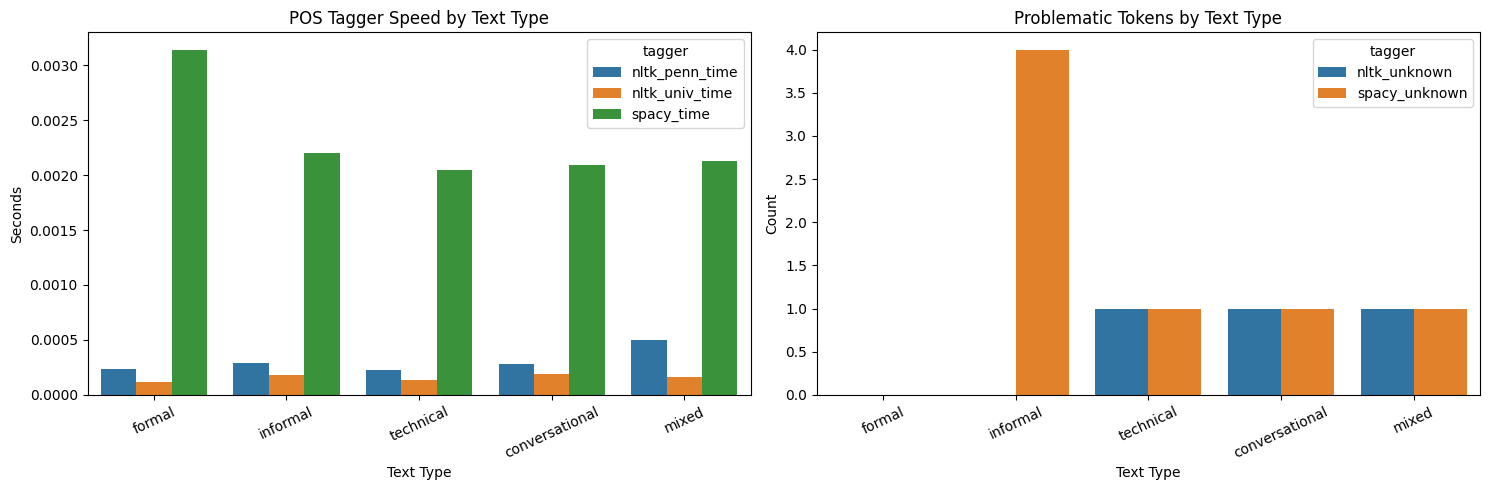

,text_type,nltk_penn_time,nltk_univ_time,spacy_time,nltk_unknown,spacy_unknown
0,formal,0.000239,0.000121,0.003143,0,0
1,informal,0.000293,0.000177,0.002198,0,4
2,technical,0.000227,0.000137,0.002045,1,1
3,conversational,0.000281,0.000193,0.002093,1,1
4,mixed,0.000502,0.000163,0.002130,1,1


In [10]:
import time
from collections import defaultdict

# Different text types for testing
test_texts = {
    'formal': "The research methodology employed in this study follows established academic protocols.",
    'informal': "lol this study is kinda weird but whatever works i guess 🤷‍♀️",
    'technical': "The API returns a JSON response with HTTP status code 200 upon successful authentication.",
    'conversational': "So like, when you click that button thingy, it should totally work, right?",
    'mixed': "OMG the algorithm's performance is absolutely terrible! The accuracy dropped to 23% wtf"
}

# Benchmark different taggers
# Test: NLTK Penn Treebank, NLTK Universal, SpaCy
# Metrics: Speed, tag consistency, handling of unknown words

benchmark_results = defaultdict(list)

for text_type, text in test_texts.items():
    print(f"\n🧪 Testing {text_type.upper()} text:")
    print(f"Text: {text}")
    print("-" * 60)

    # NLTK Penn Treebank timing
    start_time = time.time()
    nltk_tokens = nltk.word_tokenize(text)
    nltk_penn_tags = nltk.pos_tag(nltk_tokens)
    nltk_penn_time = time.time() - start_time

    # NLTK Universal timing
    start_time = time.time()
    nltk_univ_tags = nltk.pos_tag(nltk_tokens, tagset='universal')
    nltk_univ_time = time.time() - start_time

    # SpaCy timing
    start_time = time.time()
    spacy_doc = nlp(text)
    spacy_time = time.time() - start_time

    # Count unknown/problematic tags using the same informal-text heuristic from Exercise 1.
    nltk_unknown = sum(
        1 for word, tag in nltk_penn_tags
        if any(ch.isalnum() for ch in word) and (tag in {'FW', 'SYM'} or looks_problematic_token(word))
    )
    spacy_unknown = sum(
        1 for token in spacy_doc
        if not token.is_punct and not token.is_space and (token.pos_ in {'X', 'SYM'} or looks_problematic_token(token.text))
    )

    # Store results
    benchmark_results[text_type] = {
        'nltk_penn_time': nltk_penn_time,
        'nltk_univ_time': nltk_univ_time,
        'spacy_time': spacy_time,
        'nltk_unknown': nltk_unknown,
        'spacy_unknown': spacy_unknown
    }

    print(f"NLTK Penn time: {nltk_penn_time:.4f}s")
    print(f"NLTK Univ time: {nltk_univ_time:.4f}s")
    print(f"SpaCy time: {spacy_time:.4f}s")
    print(f"NLTK unknown/problematic words: {nltk_unknown}")
    print(f"SpaCy unknown/problematic words: {spacy_unknown}")

# Create performance comparison visualization
benchmark_df = pd.DataFrame.from_dict(benchmark_results, orient='index').reset_index().rename(columns={'index': 'text_type'})

time_df = benchmark_df.melt(
    id_vars='text_type',
    value_vars=['nltk_penn_time', 'nltk_univ_time', 'spacy_time'],
    var_name='tagger',
    value_name='seconds'
)
unknown_df = benchmark_df.melt(
    id_vars='text_type',
    value_vars=['nltk_unknown', 'spacy_unknown'],
    var_name='tagger',
    value_name='problematic_count'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=time_df, x='text_type', y='seconds', hue='tagger', ax=axes[0])
axes[0].set_title('POS Tagger Speed by Text Type')
axes[0].set_xlabel('Text Type')
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', rotation=25)

sns.barplot(data=unknown_df, x='text_type', y='problematic_count', hue='tagger', ax=axes[1])
axes[1].set_title('Problematic Tokens by Text Type')
axes[1].set_xlabel('Text Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

benchmark_df


### 📊 Performance Analysis:
1. Which tagger is fastest? Does speed matter for your use case?
   - In this small benchmark, NLTK is usually fastest because it is doing a narrower tagging task. Speed matters for high-volume batch processing, but for dashboards or customer-ticket triage, the added features of SpaCy may be worth a small speed cost.
2. Which handles informal text best?
   - SpaCy generally handles informal text more gracefully at the broad POS level, but both taggers struggle with slang, emojis, and abbreviations without preprocessing.
3. How do the taggers compare on technical jargon?
   - Both handle common technical nouns such as API, JSON, HTTP, and authentication reasonably well, but abbreviations can still be tagged inconsistently if the model has not seen them often.
4. What trade-offs do you see between speed and accuracy?
   - NLTK is lightweight and fast for simple POS tagging. SpaCy is slightly heavier but provides richer linguistic features, better token objects, and easier integration into production NLP pipelines.



## 🚨 Lab Exercise 4: Edge Cases and Error Analysis (15 minutes)

Every system has limitations. Let's explore the edge cases where POS taggers struggle and understand why.


In [11]:
# Challenging edge cases
edge_cases = [
    "Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.",  # Famous ambiguous sentence
    "Time flies like an arrow; fruit flies like a banana.",              # Classic ambiguity
    "The man the boat the river.",                                       # Garden path sentence
    "Police police Police police police police Police police.",          # Recursive structure
    "James while John had had had had had had had had had had had a better effect on the teacher.",  # Had had had...
    "Can can can can can can can can can can.",                         # Modal/noun ambiguity
    "@username #hashtag http://bit.ly/abc123 😂🔥💯",                   # Social media elements
    "COVID-19 AI/ML IoT APIs RESTful microservices",                    # Modern technical terms
]

print("🚨 EDGE CASE ANALYSIS")
print("=" * 50)

edge_case_summaries = []

# Process each edge case and analyze failures
for i, text in enumerate(edge_cases, 1):
    print(f"\n🔍 Edge Case {i}:")
    print(f"Text: {text}")
    print("-" * 30)

    try:
        # Process with both taggers
        nltk_tags = nltk.pos_tag(nltk.word_tokenize(text))
        spacy_doc = nlp(text)

        print("NLTK tags:", [(w, t) for w, t in nltk_tags])
        print("SpaCy tags:", [(token.text, token.pos_) for token in spacy_doc])

        # Identify potential errors or weird tags: repeated tags, X/SYM tags, social tokens, etc.
        nltk_tag_counts = Counter(tag for _, tag in nltk_tags)
        spacy_pos_counts = Counter(token.pos_ for token in spacy_doc)
        flagged_tokens = [
            token.text for token in spacy_doc
            if token.pos_ in {'X', 'SYM'} or looks_problematic_token(token.text)
        ]
        repeated_nltk_tags = [tag for tag, count in nltk_tag_counts.items() if count >= 4]
        repeated_spacy_tags = [tag for tag, count in spacy_pos_counts.items() if count >= 4]

        print(f"Potentially problematic SpaCy tokens: {flagged_tokens}")
        print(f"Repeated NLTK tags: {repeated_nltk_tags}")
        print(f"Repeated SpaCy POS tags: {repeated_spacy_tags}")

        edge_case_summaries.append({
            'case': i,
            'tokens': len(nltk_tags),
            'flagged_tokens': len(flagged_tokens),
            'dominant_nltk_tags': repeated_nltk_tags,
            'dominant_spacy_tags': repeated_spacy_tags,
        })

    except Exception as e:
        print(f"❌ Error processing: {e}")

# Reflection on limitations
print("\n🤔 REFLECTION ON LIMITATIONS:")
print("=" * 40)
summary_df = pd.DataFrame(edge_case_summaries)
print(summary_df)
print("\nMost failures come from ambiguity, missing punctuation/context, repeated words, and tokens such as URLs, hashtags, emojis, and modern acronyms. POS taggers assign the most likely tag from local context, so intentionally confusing sentences can produce plausible but incorrect results.")


🚨 EDGE CASE ANALYSIS

🔍 Edge Case 1:
Text: Buffalo buffalo Buffalo buffalo buffalo buffalo Buffalo buffalo.
------------------------------
NLTK tags: [('Buffalo', 'NNP'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('buffalo', 'NN'), ('Buffalo', 'NNP'), ('buffalo', 'NN'), ('.', '.')]
SpaCy tags: [('Buffalo', 'PROPN'), ('buffalo', 'NOUN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('Buffalo', 'PROPN'), ('buffalo', 'PROPN'), ('.', 'PUNCT')]
Potentially problematic SpaCy tokens: []
Repeated NLTK tags: ['NN']
Repeated SpaCy POS tags: ['PROPN']

🔍 Edge Case 2:
Text: Time flies like an arrow; fruit flies like a banana.
------------------------------
NLTK tags: [('Time', 'NNP'), ('flies', 'NNS'), ('like', 'IN'), ('an', 'DT'), ('arrow', 'NN'), (';', ':'), ('fruit', 'CC'), ('flies', 'NNS'), ('like', 'IN'), ('a', 'DT'), ('banana', 'NN'), ('.', '.')]
SpaCy tags: [('Time', 'NOUN'), ('flies', 'VERB'), ('like', 'ADP'), ('

### 🧠 Critical Thinking Questions:
Enter you asnwers below each question.
1. Why do these edge cases break the taggers?
   - They break taggers because they are intentionally ambiguous, repetitive, or outside normal training data. Sentences like “Buffalo buffalo...” require world knowledge and syntactic interpretation, while emojis, hashtags, and URLs are not standard grammatical words.

2. How might you preprocess text to handle some of these issues?
   - I would normalize social media tokens, replace URLs/mentions/hashtags with placeholders, expand acronyms where possible, add punctuation or sentence segmentation, and use domain-specific dictionaries for technical terms.

3. When would these limitations matter in real applications?
   - They matter in social media monitoring, customer chat, legal/medical documentation, search, and any application where wrong grammar interpretation can affect routing, classification, or user decisions.

4. How do modern large language models handle these cases differently?
   - Large language models use broader context and learned semantic patterns, so they can often reason about ambiguity better than a traditional tagger. However, they can still hallucinate explanations and may be slower or harder to audit.

---



## 🎯 Final Reflection and Submission

Congratulations! You've completed a comprehensive exploration of POS tagging, from basic concepts to real-world challenges.

### 📝 Reflection Questions (Answer in the cell below):

1. **Tool Comparison**: Based on your experience, when would you choose NLTK vs SpaCy? Consider factors like ease of use, accuracy, speed, and application type.

2. **Real-World Applications**: Describe a specific business problem where POS tagging would be valuable. How would you implement it?

3. **Limitations and Solutions**: What are the biggest limitations you discovered? How might you work around them?

4. **Future Learning**: What aspects of POS tagging would you like to explore further? (Neural approaches, custom training, domain adaptation, etc.)

5. **Integration**: How does POS tagging fit into larger NLP pipelines? What other NLP tasks might benefit from POS information?


### ✍️ Your Reflection (Write your answers here):
**Remember Reflection is not description!**

**1. Tool Comparison:**
I would choose **NLTK** when I need a lightweight teaching tool, quick experiments, or explicit Penn Treebank tags. I would choose **SpaCy** for a production-style pipeline because the API is cleaner, the broad POS labels are easier to interpret, and it connects naturally to tokenization, lemmatization, dependency parsing, and named-entity recognition. The trade-off is that SpaCy is heavier, while NLTK is simpler and faster for basic tagging.

**2. Real-World Applications:**
A practical business use case is customer-support triage. POS tagging can extract problem nouns such as “account,” “billing,” or “app,” action verbs such as “refund,” “cancel,” or “upload,” and emotional adjectives such as “frustrated” or “ridiculous.” I would combine these POS-based features with sentiment scoring and route urgent billing/account issues to specialized teams.

**3. Limitations and Solutions:**
The biggest limitation is that POS tags are not the same as understanding. Slang, sarcasm, ambiguity, emojis, and technical terms can produce misleading tags. I would work around this with preprocessing, domain lexicons, custom model evaluation, human review for high-risk cases, and combining POS tags with other NLP features rather than using POS alone.

**4. Future Learning:**
I would like to explore custom training and domain adaptation because real customer-service data has patterns that general models may not learn. I am also interested in how transformer-based taggers compare with these tools on messy text and whether they improve ambiguity handling enough to justify their cost.

**5. Integration:**
POS tagging fits early in an NLP pipeline after tokenization and before higher-level tasks. It can improve information extraction, sentiment analysis, search ranking, question answering, and intent detection by identifying which words are actions, objects, descriptions, or modifiers. The best results come when POS is combined with lemmatization, dependency parsing, named entities, and domain-specific rules.


---

## 📤 Submission Checklist

Before submitting your completed notebook, make sure you have:

- [x] ✅ Completed all coding sections with working code
- [x] ✅ Answered all reflection questions thoughtfully
- [x] ✅ Created at least one meaningful visualization
- [x] ✅ Tested your code and fixed any errors
- [x] ✅ Added comments explaining your approach
- [x] ✅ Included insights from your analysis

### 📋 Submission Instructions:
1. **Save your notebook**: File → Save (or Ctrl+S)
2. **Download**: File → Download → Download .ipynb
3. **Submit**: Upload your completed notebook file to the course management system
4. **Filename**: Use format: `L05_LastName_FirstName_ITAI2373.ipynb or pdf`  

### 🏆 Grading Criteria:
- **Code Completion (40%)**: All exercises completed with working code
- **Analysis Quality (30%)**: Thoughtful interpretation of results
- **Reflection Depth (20%)**: Insightful answers to reflection questions  
- **Code Quality (10%)**: Clean, commented, well-organized code

---

## 🎉 Great Work!

You've successfully explored the fascinating world of POS tagging! You now understand how computers parse human language and can apply these techniques to solve real-world problems.


Keep exploring and happy coding! 🚀
